# Calibrate Erosion-Ratio Hard/Normal Metric

Calibrate only the local erosion-ratio metric for hard versus normal ore. The metric is calculated per local mineral-mask window as `sum(area(eroded class_i mask)) / sum(area(class_i mask))`, then bilinearly interpolated to full image size. Sparse windows with ore area below `MIN_ORE_FRACTION` receive metric `0`.

High erosion ratio means each mineral class remains compact after erosion and is treated as normal ore. Low erosion ratio means the mask is fragmented, thin, ragged, or split into many close mineral-class blocks and is treated as hard ore.

In [1]:
from pathlib import Path
import json
import sys

from PIL import Image
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from ore_detection.data.inventory import inventory_baseline_images
from ore_detection.descriptors.erosion_ratio import (
    ErosionRatioConfig,
    choose_erosion_ratio_threshold,
    classify_erosion_ratio_intergrowth,
    mean_ore_ratio_score,
    save_erosion_ratio_config,
)

BASELINE_ROOT = PROJECT_ROOT / 'datasets' / 'baseline'
PREDICTION_ROOT = PROJECT_ROOT / 'data_work' / 'predictions' / 'model_segmentation' / 'baseline_crops'
CONFIG_PATH = PROJECT_ROOT / 'models' / 'intergrowth_erosion_ratio' / '001' / 'classifier.json'

RUN_CALIBRATION = True
EROSION_KERNEL_SIZE = 5      # square erosion window size; must be odd
EROSION_ITERATIONS = 3       # erosion time / repeat count
WINDOW_SIZE = 128            # local metric window size
NORMAL_THRESHOLD = 0.4       # normal if interpolated metric is greater than this
MIN_ORE_FRACTION = 0.05      # metric is 0 when ore area in the window is below 5%
REVIEW_LIMIT = 5

config = ErosionRatioConfig(
    erosion_kernel_size=EROSION_KERNEL_SIZE,
    erosion_iterations=EROSION_ITERATIONS,
    window_size=WINDOW_SIZE,
    normal_threshold=NORMAL_THRESHOLD,
    min_ore_fraction=MIN_ORE_FRACTION,
)
config.validate()

print(f'baseline root: {BASELINE_ROOT}')
print(f'prediction root: {PREDICTION_ROOT}')
print(f'config path: {CONFIG_PATH}')
print(json.dumps(config.to_dict(), indent=2))

baseline root: C:\Users\Cape\PycharmProjects\ore_detection\datasets\baseline
prediction root: C:\Users\Cape\PycharmProjects\ore_detection\data_work\predictions\model_segmentation\baseline_crops
config path: C:\Users\Cape\PycharmProjects\ore_detection\models\intergrowth_erosion_ratio\001\classifier.json
{
  "model_type": "local_erosion_ratio_score",
  "version": 1,
  "erosion_kernel_size": 5,
  "erosion_iterations": 3,
  "window_size": 128,
  "normal_threshold": 0.4,
  "min_ore_fraction": 0.05,
  "class_ids": {
    "background": 0,
    "talc": 3,
    "normal_ore": 4,
    "hard_ore": 5,
    "ignore": 255
  }
}


## Load Baseline Crop Records

This notebook uses existing prediction folders created by `04_predict_ore_masks_and_descriptors.ipynb`. It does not run segmentation models.

In [2]:
baseline_records = inventory_baseline_images(BASELINE_ROOT)
baseline_records = sorted(baseline_records, key=lambda row: (row['part'], row['label'], row['path']))
label_counts = {}
for record in baseline_records:
    label_counts[str(record['label'])] = label_counts.get(str(record['label']), 0) + 1
print('baseline crop count (panoramas skipped):', len(baseline_records))
print(label_counts)

BASELINE_ROOT_RESOLVED = BASELINE_ROOT.resolve()

def is_baseline_crop_path(path):
    path = Path(path).resolve()
    try:
        rel = path.relative_to(BASELINE_ROOT_RESOLVED)
    except ValueError:
        return False
    return len(rel.parts) >= 3 and 'panoramas' not in {part.lower() for part in rel.parts}

def baseline_crop_key(path):
    path = Path(path).resolve()
    try:
        return str(path.relative_to(BASELINE_ROOT_RESOLVED)).casefold()
    except ValueError:
        return str(path).casefold()

def expected_prediction_dir_for_record(record):
    sample_id = f"{record['part']}_{record['label']}_{Path(record['path']).stem}".replace(' ', '_')
    return PREDICTION_ROOT / sample_id

def prediction_dirs_by_image_path():
    matched = {}
    skipped_panorama_predictions = 0
    missing_or_bad_metadata = 0
    if not PREDICTION_ROOT.exists():
        return matched
    for sample_dir in sorted(path for path in PREDICTION_ROOT.glob('*') if path.is_dir() and (path / 'ore_mask.png').exists()):
        metadata_path = sample_dir / 'metadata.json'
        if not metadata_path.exists():
            missing_or_bad_metadata += 1
            continue
        try:
            metadata = json.loads(metadata_path.read_text(encoding='utf-8'))
        except json.JSONDecodeError:
            missing_or_bad_metadata += 1
            continue
        image_value = metadata.get('image_path')
        if not image_value:
            missing_or_bad_metadata += 1
            continue
        image_path = Path(image_value)
        image_path = image_path.resolve() if image_path.is_absolute() else (PROJECT_ROOT / image_path).resolve()
        if not is_baseline_crop_path(image_path):
            skipped_panorama_predictions += 1
            continue
        matched[baseline_crop_key(image_path)] = sample_dir
    print(f'prediction dirs matched by metadata: {len(matched)}')
    print(f'prediction dirs skipped as panoramas: {skipped_panorama_predictions}')
    print(f'prediction dirs skipped for missing/bad metadata: {missing_or_bad_metadata}')
    return matched

prediction_dir_by_image_key = prediction_dirs_by_image_path()

def prediction_dir_for_record(record):
    return prediction_dir_by_image_key.get(baseline_crop_key(record['path']), expected_prediction_dir_for_record(record))


baseline crop count (panoramas skipped): 1222
{'Hard ore': 486, 'Normal ore': 565, 'Talc contained': 171}
prediction dirs matched by metadata: 25
prediction dirs skipped as panoramas: 0
prediction dirs skipped for missing/bad metadata: 0


## Calibrate Threshold

The image-level calibration proxy is the mean interpolated erosion-ratio score over predicted ore pixels. Normal ore should have higher values; hard ore should have lower values. When `ore_multiclass_mask.png` exists, erosion is calculated for each non-background mineral class separately and then summed. `Talc contained` crops are skipped for threshold fitting because talc is a separate manual class.

In [3]:
def image_score_from_prediction(prediction_dir, config):
    multiclass_path = prediction_dir / 'ore_multiclass_mask.png'
    with Image.open(prediction_dir / 'ore_mask.png') as mask:
        multiclass = Image.open(multiclass_path).convert('L') if multiclass_path.exists() else None
        try:
            result = classify_erosion_ratio_intergrowth(mask, multiclass_mask=multiclass, config=config)
            return mean_ore_ratio_score(result.normal_score, mask)
        finally:
            if multiclass is not None:
                multiclass.close()

labeled_scores = []
diagnostic_scores = []
matched_prediction_counts = {}
missing_prediction_counts = {}
if RUN_CALIBRATION:
    for record in baseline_records:
        prediction_dir = prediction_dir_for_record(record)
        label = str(record['label'])
        if not (prediction_dir / 'ore_mask.png').exists():
            missing_prediction_counts[label] = missing_prediction_counts.get(label, 0) + 1
            continue
        score = image_score_from_prediction(prediction_dir, config)
        matched_prediction_counts[label] = matched_prediction_counts.get(label, 0) + 1
        if label in {'Normal ore', 'Hard ore'}:
            labeled_scores.append((score, label))
        else:
            diagnostic_scores.append((score, label, record['path']))

    print('matched prediction counts:', matched_prediction_counts)
    print('missing prediction counts:', missing_prediction_counts)
    labels_with_scores = {label for _, label in labeled_scores}
    if not {'Normal ore', 'Hard ore'} <= labels_with_scores:
        print('Need both Normal ore and Hard ore prediction masks before saving a calibrated threshold.')
        print('Run notebook 04 with RUN_PREDICTION=True and SAMPLE_LIMIT=None to create all baseline crop predictions.')
        print(json.dumps(config.to_dict(), indent=2))
    else:
        threshold = choose_erosion_ratio_threshold(labeled_scores)
        calibrated = ErosionRatioConfig(
            erosion_kernel_size=EROSION_KERNEL_SIZE,
            erosion_iterations=EROSION_ITERATIONS,
            window_size=WINDOW_SIZE,
            normal_threshold=threshold['threshold'],
            min_ore_fraction=MIN_ORE_FRACTION,
        )
        save_erosion_ratio_config(calibrated, CONFIG_PATH)
        config = calibrated
        print('chosen threshold:', threshold)
        print('saved:', CONFIG_PATH)
else:
    print('RUN_CALIBRATION is False; using manual parameters only.')
    print(json.dumps(config.to_dict(), indent=2))

matched prediction counts: {'Hard ore': 25}
missing prediction counts: {'Hard ore': 461, 'Normal ore': 565, 'Talc contained': 171}
Need both Normal ore and Hard ore prediction masks before saving a calibrated threshold.
Run notebook 04 with RUN_PREDICTION=True and SAMPLE_LIMIT=None to create all baseline crop predictions.
{
  "model_type": "local_erosion_ratio_score",
  "version": 1,
  "erosion_kernel_size": 5,
  "erosion_iterations": 3,
  "window_size": 128,
  "normal_threshold": 0.4,
  "min_ore_fraction": 0.05,
  "class_ids": {
    "background": 0,
    "talc": 3,
    "normal_ore": 4,
    "hard_ore": 5,
    "ignore": 255
  }
}


## Visual Review

Each row shows raw image, mineral mask, hard ore score, and normal ore score. The mineral mask uses `ore_multiclass_mask.png` when available and falls back to the binary ore mask otherwise. Scores use class-aware erosion for the same mineral mask shown in the second panel.

prediction dirs available for visual review: 1071


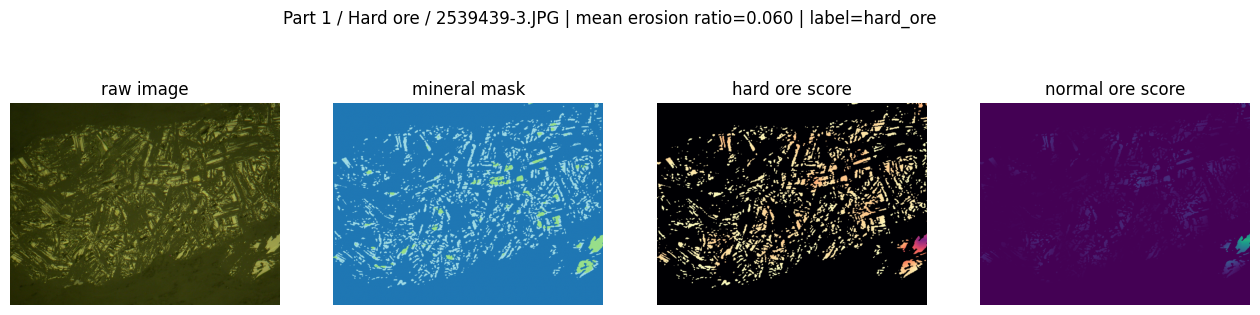

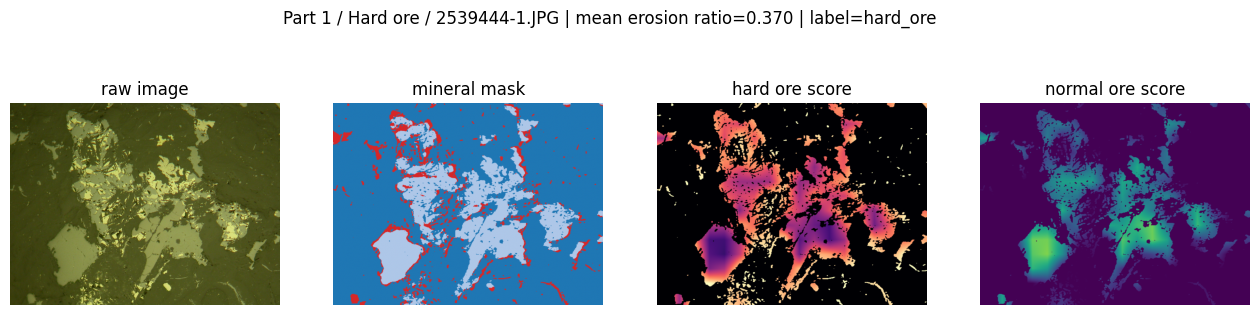

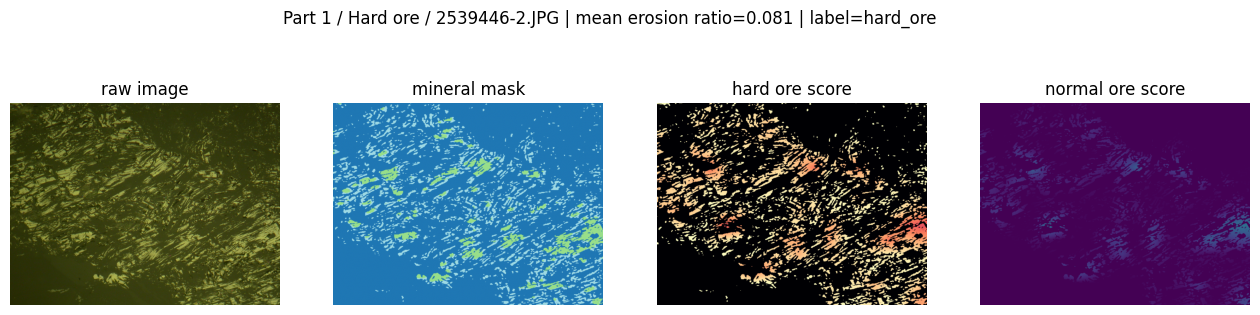

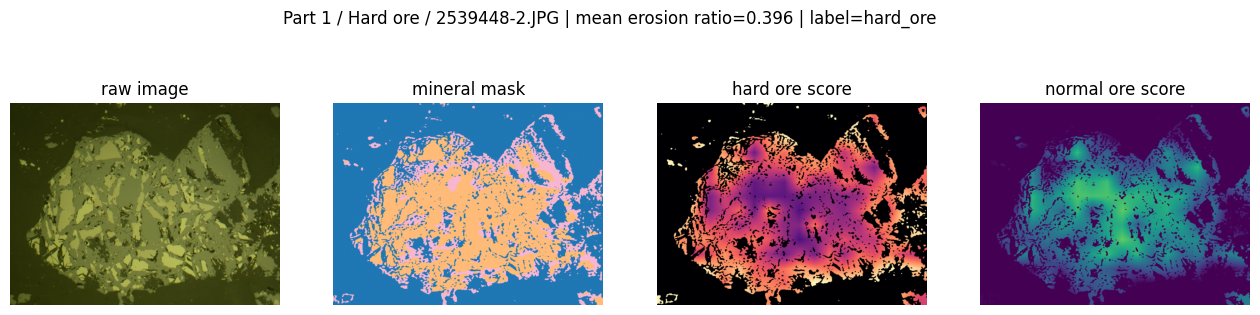

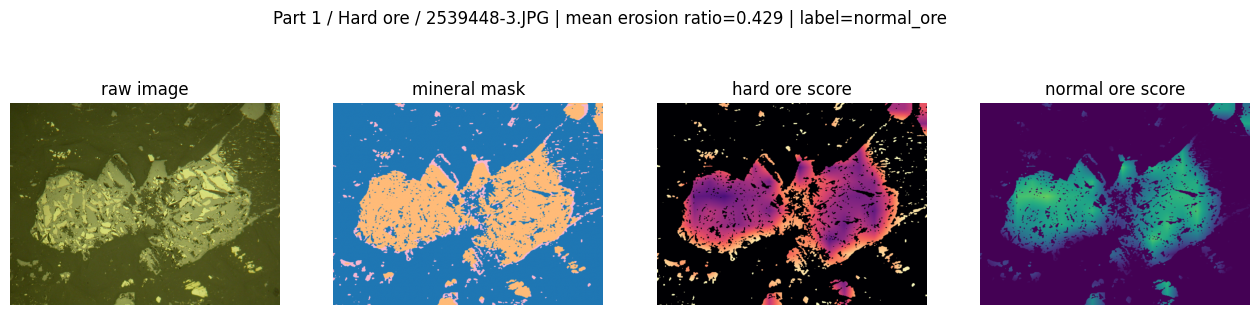

In [7]:
def load_mineral_preview(sample_dir, ore_mask):
    multiclass_path = sample_dir / 'ore_multiclass_mask.png'
    if multiclass_path.exists():
        return Image.open(multiclass_path).convert('L'), 'mineral mask'
    return ore_mask.convert('L').copy(), 'mineral mask (binary fallback)'

review_records = []
for record in baseline_records:
    prediction_dir = prediction_dir_for_record(record)
    if (prediction_dir / 'ore_mask.png').exists():
        review_records.append((record, prediction_dir))

print(f'prediction dirs available for visual review: {len(review_records)}')

for record, sample_dir in review_records[:5]:
    metadata_path = sample_dir / 'metadata.json'
    if metadata_path.exists():
        metadata = json.loads(metadata_path.read_text(encoding='utf-8'))
        image_path = Path(metadata.get('image_path', record['path']))
    else:
        image_path = Path(record['path'])

    with Image.open(image_path) as raw, Image.open(sample_dir / 'ore_mask.png') as mask:
        mask_l = mask.convert('L')
        mineral_preview, mineral_title = load_mineral_preview(sample_dir, mask_l)
        multiclass_for_score = mineral_preview if mineral_title == 'mineral mask' else None
        result = classify_erosion_ratio_intergrowth(mask_l, multiclass_mask=multiclass_for_score, config=config)
        mean_score = mean_ore_ratio_score(result.normal_score, mask_l)
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        axes[0].imshow(raw.convert('RGB'))
        axes[0].set_title('raw image')
        axes[1].imshow(mineral_preview, cmap='tab20')
        axes[1].set_title(mineral_title)
        axes[2].imshow(result.hard_score, cmap='magma', vmin=0, vmax=255)
        axes[2].set_title('hard ore score')
        axes[3].imshow(result.normal_score, cmap='viridis', vmin=0, vmax=255)
        axes[3].set_title('normal ore score')
        fig.suptitle(
            f"{record['part']} / {record['label']} / {Path(record['path']).name} | "
            f"mean erosion ratio={mean_score:.3f} | "
            f"label={result.metrics['image_label']}"
        )
        for ax in axes:
            ax.axis('off')
        plt.show()
        mineral_preview.close()